# BTCUSDC Order-Flow Study: Generalized Imbalance Scaling

This notebook is the first paper-style analysis notebook for the BTCUSDC adaptation.

We use Binance `BTCUSDC` data for `20260223` and work directly on raw trades.

The core object is the generalized raw-trade imbalance:

`I_T^a = sum epsilon_t q_t^a`

where:

- `T` is the rolling trade-count window,
- `epsilon_t` is the aggressor sign,
- `q_t` is trade size,
- `a` controls how strongly larger trades are weighted.

This notebook focuses on:

- clipping policy for extreme `qty`,
- imbalance distributions for several `T` and `a`,
- even-moment scaling of `I_T^a` versus `T`,
- effective log-log slopes as a function of `a`.

Design choice:

- we stay on raw trades rather than `1-second` bars,
- because the paper's object is defined on child orders / trades rather than clock-time buckets.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
from pathlib import Path
import importlib.util

def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / "notebooks" / "notebook_utils.py"
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location("notebook_utils", utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f"Could not load notebook utilities from {utils_path}")
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError("Could not locate notebooks/notebook_utils.py")

notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()
find_backtester_root = notebook_utils.find_backtester_root
resolve_day_dir = notebook_utils.resolve_day_dir


In [3]:
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_trades_table


symbol = "ONDOUSDC"
day = "20260228"
day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)

dataset = load_day(day_dir)
trades = get_or_build_trades_table(dataset)
replay_info = replay_summary(dataset, replay_on_gap="skip-segment")

day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/ONDOUSDC/20260228')

## Data Summary

We keep this notebook on the cached enriched trades table and work in trade time rather than clock time.


In [4]:
summary = pd.Series({
    "exchange": dataset.exchange,
    "symbol": dataset.symbol,
    "day": dataset.day,
    "day_dir": str(dataset.day_dir),
    "trades_rows": len(trades),
    "trade_start_utc": trades["ts"].min() if not trades.empty else pd.NaT,
    "trade_end_utc": trades["ts"].max() if not trades.empty else pd.NaT,
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
    "segments_skipped": replay_info["segments_skipped"],
})

display(summary.to_frame("value"))
display(trades[["event_time_ms", "trade_time_ms", "price", "qty", "aggr_sign", "signed_qty", "notional", "ts"]].head())


,value
exchange,binance
symbol,ONDOUSDC
day,20260228
day_dir,/Users/hoangdeveloper/PycharmProjects/exchange...
trades_rows,5726
trade_start_utc,2026-02-28 01:00:31.827000+00:00
trade_end_utc,2026-02-28 23:14:30.844000+00:00
segments_total,1
segments_kept,1
segments_skipped,0


,event_time_ms,trade_time_ms,price,qty,aggr_sign,signed_qty,notional,ts
0,1772240431824,1772240431824,0.2582,50.8,1.0,50.8,13.11656,2026-02-28 01:00:31.827000+00:00
1,1772240447950,1772240447949,0.2583,47.3,1.0,47.3,12.21759,2026-02-28 01:00:47.953000+00:00
2,1772240447950,1772240447949,0.2583,43.8,1.0,43.8,11.31354,2026-02-28 01:00:47.954000+00:00
3,1772240447950,1772240447949,0.2583,320.6,1.0,320.6,82.81098,2026-02-28 01:00:47.955000+00:00
4,1772240447950,1772240447949,0.2584,320.6,1.0,320.6,82.84304,2026-02-28 01:00:47.955000+00:00


## Why Raw Trades Instead Of Time Bars

The old notebook used `1-second` bars as a baseline because they aligned imbalance and returns on one clock and reduced tape irregularity.

For this notebook we switch to raw trades because:

- `T` should count flow units directly,
- time bars hide within-second sign persistence,
- the paper's imbalance object is defined on child orders / trades rather than clock-time buckets.


## Quantity Policy And Clipping

The paper clips extreme child-order sizes because very large outliers can dominate moment estimates for larger `a`.

We keep two versions here:

- `raw`: use the observed `qty`,
- `clipped`: cap `qty` at `1%` of the day's total traded quantity.

That cap is intentionally close to the paper's wording even if, on some crypto days, it turns out to be loose.


In [5]:
def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def even_raw_moment(x: np.ndarray, order: int) -> float:
    if order % 2 != 0:
        raise ValueError("order must be even")
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(np.mean(np.power(np.abs(x), order)))


def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if mask.sum() < 2:
        return np.nan
    slope, _ = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
    return float(slope)


def build_weighted_signed_flow(sign: np.ndarray, qty: np.ndarray, a: float) -> np.ndarray:
    return sign * np.power(qty, a)


def build_imbalance_series(sign: np.ndarray, qty: np.ndarray, T: int, a: float) -> np.ndarray:
    weighted = build_weighted_signed_flow(sign, qty, a)
    return rolling_window_sum(weighted, T)


In [6]:
T_list = np.array([5, 10, 20, 50, 100, 200, 500, 1000], dtype=int)
a_list = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0], dtype=float)
moment_orders = [2, 4, 6]
selected_T_for_hist = [10, 20, 50, 100, 200, 500, 1000]
selected_a_for_hist = [0.0, 0.3, 1.0, 1.2]
clip_fraction_of_daily_qty = 0.01


In [7]:
work = trades[["qty", "aggr_sign", "price", "notional", "ts"]].copy()
work = work[np.isfinite(work["qty"]) & np.isfinite(work["aggr_sign"]) & (work["qty"] > 0)].copy()
work = work.reset_index(drop=True)

daily_total_qty = float(work["qty"].sum())
paper_style_clip_qty = daily_total_qty * clip_fraction_of_daily_qty
work["qty_clipped"] = work["qty"].clip(upper=paper_style_clip_qty)

clip_summary = pd.DataFrame([
    {
        "series": "raw",
        "min_qty": work["qty"].min(),
        "median_qty": work["qty"].median(),
        "p99_qty": work["qty"].quantile(0.99),
        "max_qty": work["qty"].max(),
    },
    {
        "series": "clipped",
        "min_qty": work["qty_clipped"].min(),
        "median_qty": work["qty_clipped"].median(),
        "p99_qty": work["qty_clipped"].quantile(0.99),
        "max_qty": work["qty_clipped"].max(),
    },
])

policy_summary = pd.Series({
    "trade_rows_used": len(work),
    "daily_total_qty": daily_total_qty,
    "paper_style_clip_fraction": clip_fraction_of_daily_qty,
    "paper_style_clip_qty": paper_style_clip_qty,
    "shares_above_clip": float((work["qty"] > paper_style_clip_qty).mean()),
})

display(policy_summary.to_frame("value"))
display(clip_summary)


,value
trade_rows_used,5.726000e+03
daily_total_qty,1.557001e+06
paper_style_clip_fraction,1.000000e-02
paper_style_clip_qty,1.557001e+04
shares_above_clip,1.746420e-04


,series,min_qty,median_qty,p99_qty,max_qty
0,raw,0.1,47.4,2844.725,16320.600
1,clipped,0.1,47.4,2844.725,15570.014


Interpretation: on `BTCUSDC / 20260223`, the paper-style `1%` clipping rule is effectively inactive because no trade exceeds the cap. We keep clipping in the notebook anyway because it is part of the paper's methodology and will matter more on days with larger outliers or in later multi-day comparisons.


## Imbalance Inputs

We keep the trade sign fixed and compare two size series: raw `qty` and clipped `qty`.


In [8]:
sign = work["aggr_sign"].to_numpy(dtype=float)
qty_raw = work["qty"].to_numpy(dtype=float)
qty_clipped = work["qty_clipped"].to_numpy(dtype=float)

qty_versions = {
    "raw": qty_raw,
    "clipped": qty_clipped,
}

pd.Series({name: values[:5].tolist() for name, values in qty_versions.items()})


raw        [50.8, 47.3, 43.8, 320.6, 320.6]
clipped    [50.8, 47.3, 43.8, 320.6, 320.6]
dtype: object

## Distribution Of Generalized Imbalance

We start with representative histograms before fitting any scaling law.
The point is to see how the imbalance shape changes with trade-count horizon `T` and weighting exponent `a`.
This section now includes `T=1000` and `a=1.2` alongside the earlier values, so the larger-window and heavier-size-weight regimes are visible in the same set of plots.


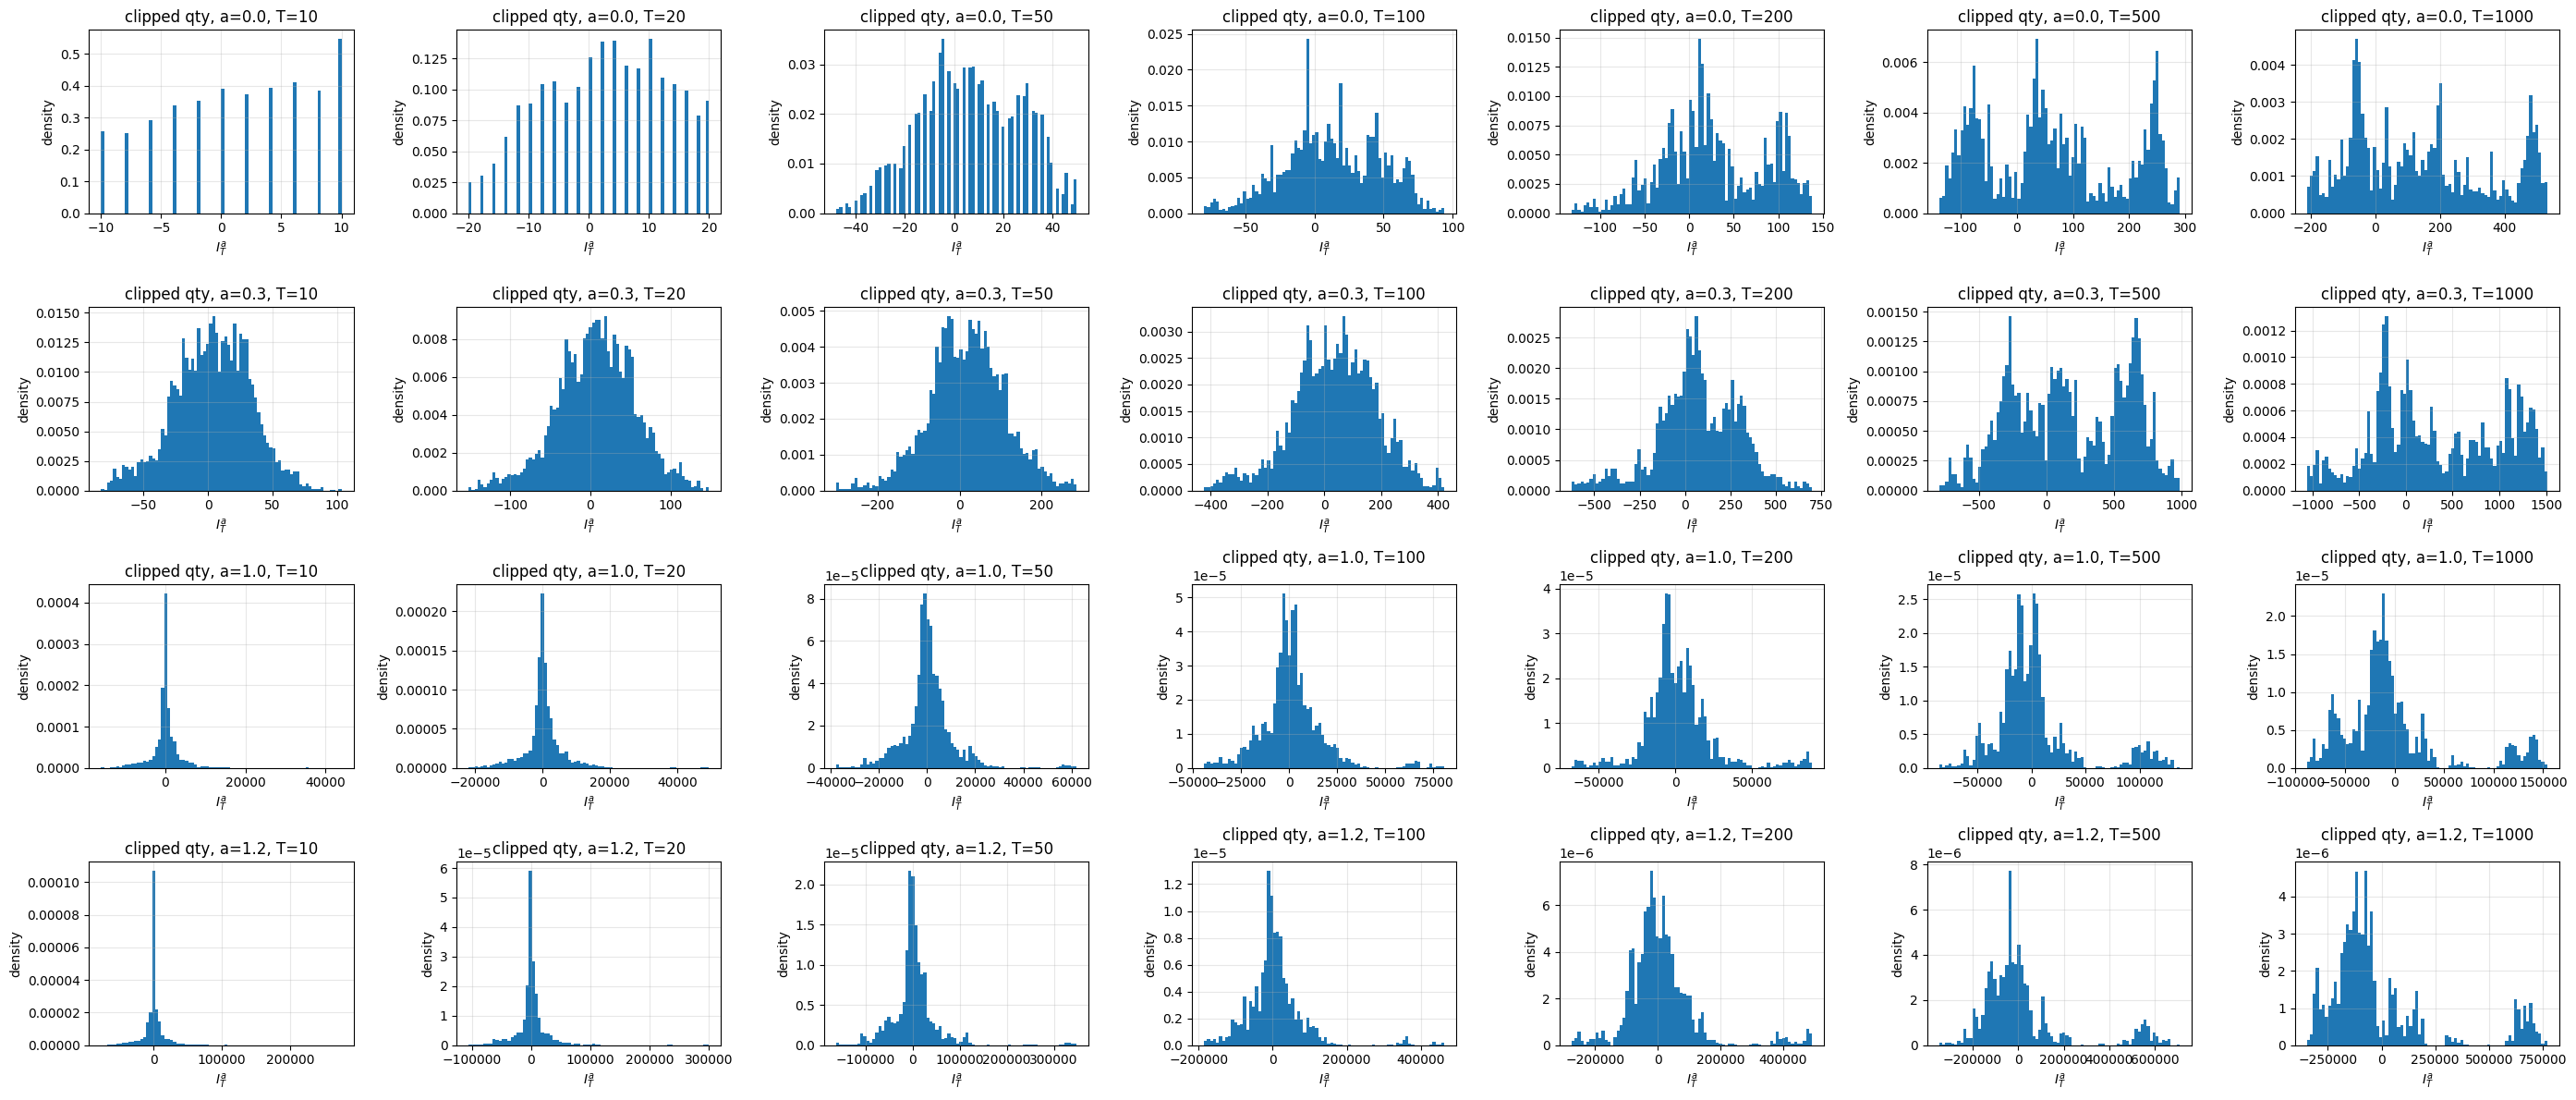

In [9]:
fig, axes = plt.subplots(len(selected_a_for_hist), len(selected_T_for_hist), figsize=(4 * len(selected_T_for_hist), 3 * len(selected_a_for_hist)), sharey=False)

for row, a in enumerate(selected_a_for_hist):
    for col, T in enumerate(selected_T_for_hist):
        ax = axes[row, col] if len(selected_a_for_hist) > 1 else axes[col]
        I = build_imbalance_series(sign, qty_clipped, T=T, a=a)
        I = I[np.isfinite(I)]
        ax.hist(I, bins=80, density=True)
        ax.set_title(f"clipped qty, a={a}, T={T}")
        ax.set_xlabel(r"$I_T^a$")
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


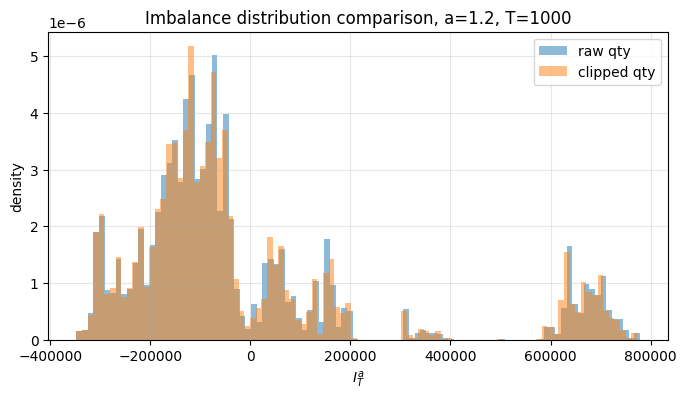

In [10]:
compare_T = 1000
compare_a = 1.2

I_raw_compare = build_imbalance_series(sign, qty_raw, T=compare_T, a=compare_a)
I_clip_compare = build_imbalance_series(sign, qty_clipped, T=compare_T, a=compare_a)

plt.figure(figsize=(8, 4))
plt.hist(I_raw_compare[np.isfinite(I_raw_compare)], bins=100, density=True, alpha=0.5, label="raw qty")
plt.hist(I_clip_compare[np.isfinite(I_clip_compare)], bins=100, density=True, alpha=0.5, label="clipped qty")
plt.title(f"Imbalance distribution comparison, a={compare_a}, T={compare_T}")
plt.xlabel(r"$I_T^a$")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Even-Moment Scaling

We now estimate even raw moments of `I_T^a` across a grid of `T` and `a`.
This is the first direct paper-style scaling object in the notebook.


## Mathematical Justification For Moment Scaling

Define the trade-level signed flow as:

`X_t^a = epsilon_t q_t^a`

and the rolling imbalance as the partial sum:

`I_T^a = X_1^a + X_2^a + ... + X_T^a`

So moment scaling is a question about how the distribution of this partial sum changes as we aggregate more trades.

For independent, centered signed flow with finite variance, variances add:

`E[(I_T^a)^2] = Var(I_T^a) = T Var(X^a)`

so the second moment grows linearly with `T`. More generally, by the central limit theorem:

`I_T^a / sqrt(T) -> Normal`

which implies the independent-flow baseline:

`E[|I_T^a|^p] ~ T^(p / 2)`

For the even moments used below, the baseline slopes are therefore:

- moment order `2`: slope `1`,
- moment order `4`: slope `2`,
- moment order `6`: slope `3`.

Persistent order flow changes this because covariance terms no longer vanish. For the second moment:

`Var(I_T^a) = T gamma(0) + 2 sum_{k=1}^{T-1} (T-k) gamma(k)`

where:

`gamma(k) = Cov(X_t^a, X_{t+k}^a)`

If `gamma(k)` is positive and decays slowly, the covariance sum makes the moment grow faster than the independent baseline. In long-memory notation, if:

`gamma(k) ~ k^(-beta), 0 < beta < 1`

then approximately:

`Var(I_T^a) ~ T^(2 - beta)`

so the second-moment slope is greater than `1`.

Equivalently, if the partial sum scales like:

`I_T^a ~ T^H`

then:

`E[|I_T^a|^p] ~ T^(pH)`

Independent flow has `H = 1/2`. Persistent flow has `H > 1/2`.

The role of `a` is to choose which signed-flow process we are testing:

- `a = 0`: `X_t = epsilon_t`, pure trade-sign imbalance,
- `a = 1`: `X_t = epsilon_t q_t`, signed volume,
- larger `a`: increasingly dominated by large trades.

So if low `a` has slopes far above the independent baselines, the dominant structure is trade-sign persistence. If high `a` behaves differently, the scaling is being shaped more by the trade-size distribution and large-trade behavior.

Important caveat: these are descriptive empirical slope estimates from overlapping rolling windows, not formal hypothesis tests. A stronger validation would compare against shuffled signs, non-overlapping windows, day-by-day slopes, and bootstrap confidence intervals.

In [11]:
moment_rows = []

for qty_name, qty_values in qty_versions.items():
    for a in a_list:
        weighted = build_weighted_signed_flow(sign, qty_values, a)
        for T in T_list:
            I = rolling_window_sum(weighted, int(T))
            for moment_order in moment_orders:
                moment_rows.append({
                    "qty_version": qty_name,
                    "a": float(a),
                    "T": int(T),
                    "moment_order": int(moment_order),
                    "moment_value": even_raw_moment(I, order=moment_order),
                })

moment_df = pd.DataFrame(moment_rows)
display(moment_df.head())


,qty_version,a,T,moment_order,moment_value
0,raw,0.0,5,2,14.008039
1,raw,0.0,5,4,304.222649
2,raw,0.0,5,6,7244.710591
3,raw,0.0,10,2,40.363827
4,raw,0.0,10,4,2947.419976


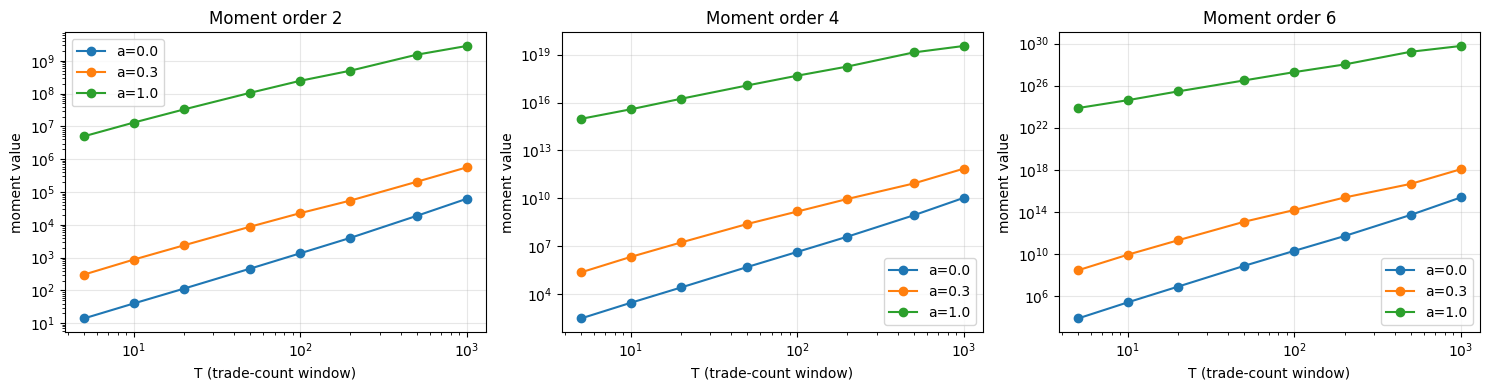

In [12]:
fig, axes = plt.subplots(1, len(moment_orders), figsize=(5 * len(moment_orders), 4), sharex=True)

for ax, moment_order in zip(np.atleast_1d(axes), moment_orders):
    for a in [0.0, 0.3, 1.0]:
        tmp = moment_df[
            (moment_df["qty_version"] == "clipped")
            & (moment_df["moment_order"] == moment_order)
            & (moment_df["a"] == a)
        ].sort_values("T")
        ax.plot(tmp["T"], tmp["moment_value"], marker="o", label=f"a={a}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Moment order {moment_order}")
    ax.set_xlabel("T (trade-count window)")
    ax.set_ylabel("moment value")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Effective Scaling Exponents Versus `a`

For each even moment, we fit a simple log-log slope of the moment versus `T`.
The main question is whether the effective exponent changes materially as `a` changes.


In [13]:
slope_rows = []

for qty_name in moment_df["qty_version"].unique():
    for moment_order in moment_orders:
        for a in a_list:
            tmp = moment_df[
                (moment_df["qty_version"] == qty_name)
                & (moment_df["moment_order"] == moment_order)
                & (moment_df["a"] == a)
            ].sort_values("T")
            slope_rows.append({
                "qty_version": qty_name,
                "moment_order": int(moment_order),
                "a": float(a),
                "loglog_slope": fit_loglog_slope(tmp["T"].to_numpy(), tmp["moment_value"].to_numpy()),
            })

slope_df = pd.DataFrame(slope_rows)
display(slope_df)


,qty_version,moment_order,a,loglog_slope
0,raw,2,0.0,1.576742
1,raw,2,0.1,1.528380
2,raw,2,0.2,1.470230
3,raw,2,0.3,1.406123
4,raw,2,0.5,1.288871
5,raw,2,1.0,1.201510
6,raw,2,1.5,1.183652
7,raw,2,2.0,1.163135
8,raw,4,0.0,3.251969
9,raw,4,0.1,3.126619


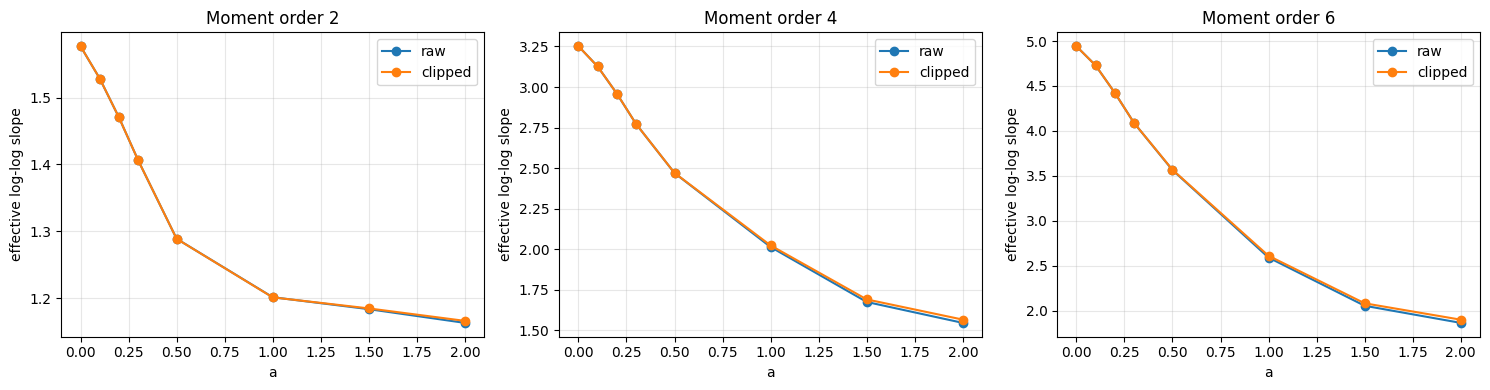

In [14]:
fig, axes = plt.subplots(1, len(moment_orders), figsize=(5 * len(moment_orders), 4), sharey=False)

for ax, moment_order in zip(np.atleast_1d(axes), moment_orders):
    for qty_name in ["raw", "clipped"]:
        tmp = slope_df[
            (slope_df["moment_order"] == moment_order)
            & (slope_df["qty_version"] == qty_name)
        ].sort_values("a")
        ax.plot(tmp["a"], tmp["loglog_slope"], marker="o", label=qty_name)
    ax.set_title(f"Moment order {moment_order}")
    ax.set_xlabel("a")
    ax.set_ylabel("effective log-log slope")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Generalized Interpretation

Use the slope table as a **relative scaling diagnostic** rather than as an absolute score. For each moment order `p`, the main comparison is between the fitted log-log slope and the independent-flow baseline `p / 2`.

How to read it in any dataset:

- if the slope is **close to the baseline**, the moment grows roughly as independent aggregation would predict;
- if the slope is **above the baseline**, the moment grows faster than independent flow, which is consistent with persistent signed flow or clustered extremes;
- if the slope is **below the baseline**, the moment grows more slowly than the independent benchmark, which usually means the weighting scheme is suppressing the long-run accumulation rather than amplifying it.

The comparison should always be made **within the same moment order** and **within the same quantity version** (`raw` or `clipped`). Do not compare the height of moment `2` against moment `6`; compare each one to its own baseline.

How to think about `a` in general:

- smaller `a` emphasizes trade-sign persistence and broad clustering;
- larger `a` gives more weight to the biggest trades, so the scaling can become dominated by the tail of the trade-size distribution;
- if raw and clipped slopes are similar, the result is more robust to large outliers;
- if raw slopes are much larger than clipped slopes, the apparent scaling is being driven by a few extreme trades.

A practical reading rule is:

- **baseline-like slopes**: weak or ordinary accumulation;
- **moderately above-baseline slopes**: some persistent order-flow structure;
- **substantially above-baseline slopes**: strong long-memory / clustering behavior;
- **slopes that flatten as `a` rises**: the signal is more about repeated sign imbalance than about very large trades.

These slope estimates are descriptive. If you want to turn them into a stronger claim, the usual next step is to compare them to a null such as shuffled signs, non-overlapping windows, or bootstrap confidence intervals.


## Picking `a` and `T`

For downstream covariance / correlation analysis, we usually do **not** want to keep every possible `(T, a)` pair. A dense grid is useful for exploration, but the next notebook should focus on a smaller set of representative values.

A practical way to choose them is:

- use a **range of `a`** during exploration, for example small to moderate values plus one or two larger values as robustness checks;
- use a **range of `T`** during exploration, from short to medium/long windows, so we can see where the scaling becomes stable;
- then keep only a few **single representative values** for the next notebook.

The reason is that the covariance / correlation notebook becomes harder to read if every point on the grid is carried forward. We want a small set of settings that capture the main regimes without turning the analysis into a giant parameter sweep.

How to pick them in general:

- choose `a` where the moment slopes are still informative and not completely flattened;
- choose `T` where the moments are stable enough to estimate, but not so large that you lose too many observations;
- keep one or two larger `a` values as stress tests;
- keep one or two larger `T` values as longer-horizon checks.

So the answer is: **use ranges for exploration, then choose a small set of single values for the downstream notebook**. If a later figure needs a sensitivity check, you can still show a narrow range around those chosen points.


## Short Takeaways

This notebook should leave us with four concrete questions for the current dataset:

- do the imbalance moments grow faster than the independent-flow baseline?
- does the effective scaling change materially with `a`?
- does clipping matter for larger `a`?
- which `(T, a)` regions are worth carrying into the return covariance / correlation notebook?

The next notebook adds trade-time price changes `Delta_T` and studies:

- covariance `E[Delta_T * I_T^a]`,
- correlation `R_a(T)`,
- how those quantities vary jointly with `T` and `a`.
